In [1]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
import math
from scipy.special import eval_hermite
from scipy.special import hermite
from matplotlib import pyplot as plt
from scipy.integrate import simpson
from functools import lru_cache

In [2]:
@lru_cache(maxsize=None)
def log_normalization_const_squared(nu, n):
    result = np.log(np.sqrt(2 * nu))
    result -= np.log(np.pow(np.pi, 1/2))
    result -= np.log(2) * (2*n)
    result -= math.lgamma(2 * n + 2)
    return result

def HO_energy(n_basis):
    diag = [2*n + 3/2 for n in range(0, n_basis)]
    energy = np.diag(diag)
    return energy


def precompute_norm_factors(M):
    log_norms = np.array([log_normalization_const_squared(0.5, k) for k in range(M)])
    return np.exp(log_norms / 2) / np.sqrt(4 * np.pi)  

def precompute_hermite_matrix(M, x_points):
    return np.array([eval_hermite(2*k+1, x_points) for k in range(M)])

def wavefunction_matrix(coefficients, x_points, hermite_matrix, norm_factors):
    weighted = (norm_factors * coefficients)[:, np.newaxis] * hermite_matrix
    psi_sum = np.sum(weighted, axis=0)
    M = len(coefficients)
    deriv_at_0 = np.array([hermite(2*k+1).deriv()(0) for k in range(M)])
    limit_at_0 = np.sum(norm_factors * coefficients * deriv_at_0) * 1.0  
    with np.errstate(divide='ignore', invalid='ignore'):
        psi = np.where(x_points != 0,
                       psi_sum / x_points * np.exp(-x_points**2 / 2),
                       limit_at_0)
    return psi

def potential_energy(coefficients, nu, N, a):
    M = len(coefficients)
    coefficients = np.asarray(coefficients)
    max_order = 6*M - 2
    points, weights = hermgauss(max_order)
    eta = np.sqrt(0.5)
    x_pts = eta * points
    norm_factors = precompute_norm_factors(M)
    hermite_matrix = precompute_hermite_matrix(M, x_pts)
    psi_vals = wavefunction_matrix(coefficients, x_pts, hermite_matrix, norm_factors)
    psi_no_exp = psi_vals / np.exp(-x_pts**2 / 2) 
    log_norms_nu = np.array([log_normalization_const_squared(nu, k) for k in range(M)])
    result = np.zeros((M, M))
    for n in range(M):
        for m in range(n, M):
            herm_nm = eval_hermite(2*m+1, x_pts) * eval_hermite(2*n+1, x_pts)
            integral = np.sum(weights / 2 * herm_nm * psi_no_exp**2)
            coeff = (N-1)*a * np.sqrt(2)/2 * 4*np.pi * np.exp(
                (log_norms_nu[n] + log_norms_nu[m]) / 2
            )
            result[n, m] = coeff * integral
            result[m, n] = result[n, m]
    return result

def hamiltonian(coefficients, old_coefficients, alpha, nu, N, a):
    M=len(coefficients)
    HO=HO_energy(M)
    potential=(alpha)*potential_energy(coefficients, nu, N, a)+(1-alpha)*potential_energy(old_coefficients, nu, N, a)
    return HO+potential


def true_energy(coefficients, N, a, mu): 
    coefficients = np.asarray(coefficients)
    ho_energy = np.sum(coefficients**2 * (2*np.arange(len(coefficients)) + 1.5))
    x = np.arange(0.001, 10, 0.001)
    M = len(coefficients)
    norm_factors = precompute_norm_factors(M)
    herm_mat = precompute_hermite_matrix(M, x)
    psi = wavefunction_matrix(coefficients, x, herm_mat, norm_factors) 
    wavefunction_integral = (N-1)*a * (4*np.pi)**2 * simpson(psi**4 * x**2, x)
    E = ho_energy + wavefunction_integral / 2
    E_difference = mu - ho_energy - wavefunction_integral
    return E, E_difference


def ground_state(old_coefficients, old_old_coefficients, alpha, nu, N, a):
    energies, vecs = np.linalg.eigh(hamiltonian(old_coefficients, old_old_coefficients, alpha, nu, N, a))
    psi = vecs[:, 0]
    if psi[np.argmax(np.abs(psi))] < 0:
        psi = -psi
    return energies[0], psi


def plot_state(coefficients, E, a,i):
    cmap = plt.get_cmap('tab20')
    x = np.arange(0.001, 6, 0.01)
    M = len(coefficients)
    norm_factors = precompute_norm_factors(M)
    herm_mat = precompute_hermite_matrix(M, x)
    y = wavefunction_matrix(np.asarray(coefficients), x, herm_mat, norm_factors)
    #plt.plot(x, y*y*x*x*4*np.pi, label=f"Na={a*1000}; "+f"E={E:.6f}")
    plt.plot(x, y*y*x*x*4*np.pi, color = cmap(i), label = f'Na = {a*1000:.0e}, E = {E:.6f}')
    plt.xlabel("Radial coordinate [h.o. length units]")
    plt.ylabel("Probability density [h.o. length units]$^{-1}$")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.title("GP equation solutions through the variational method")
    #print("Area=",(simpson(y*y*x*x*4*np.pi,x)))


E at  0  iteration=  1.8985433372730558
Delta_E at  0  iteration=  -0.7970866745461115
E at  1  iteration=  1.8154548324078104
Delta_E at  1  iteration=  -0.23290306282197537
E at  2  iteration=  1.8203079054502946
Delta_E at  2  iteration=  0.08453916620629826
E at  3  iteration=  1.8111370509996734
Delta_E at  3  iteration=  -0.009616736379771007
E at  4  iteration=  1.8115590961986776
Delta_E at  4  iteration=  -0.025512738194493734
E at  5  iteration=  1.811083486077122
Delta_E at  5  iteration=  0.010123407827832498
E at  6  iteration=  1.8109794324771706
Delta_E at  6  iteration=  0.0038563070976765923
E at  7  iteration=  1.810982960950533
Delta_E at  7  iteration=  -0.004235719496337165
E at  8  iteration=  1.8109635958384989
Delta_E at  8  iteration=  0.00011154747877795135
E at  9  iteration=  1.81096516540027
Delta_E at  9  iteration=  0.0011995739072231393
E at  10  iteration=  1.8109637462747714
Delta_E at  10  iteration=  -0.00038899926942115304
E at  11  iteration=  1.81

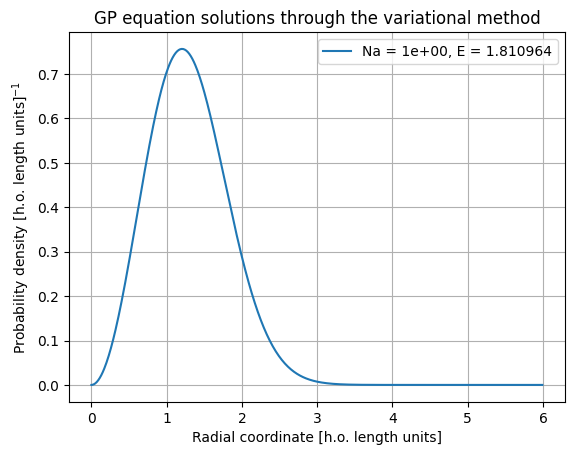

In [25]:
def iterative_GP(first_guess,alpha,nu,N,a,N_iterations,delta_E_stop,j):
    old_coord=first_guess
    old_old_coord=np.zeros(len(first_guess))
    for i in range(N_iterations):
        new_mu, new_coord=ground_state(old_coord,old_old_coord,alpha,nu,N,a)
        #if i%10==0:
            #plot_state(new_coord,i)
        #print("Mu at ",(i)," iteration= ",(new_mu))
        E, E_difference = true_energy(new_coord, N, a, new_mu)  
        print("E at ",(i)," iteration= ",(E))
        print("Delta_E at ",(i)," iteration= ",(E_difference))
        #print("Normalization=",(np.sum(new_coord**2)))
        if abs(E_difference)<delta_E_stop and i>1:
            print("Convergence reached with delta_E criterion!")
            plot_state(new_coord,E,a,j)
            break
        old_old_coord=old_coord
        old_coord=new_coord
        
    return new_mu, E, new_coord

first_guess=np.zeros(40)
#first_guess[0]=1
mixing=0.5
_,_,psi_current=iterative_GP(first_guess,mixing,0.5,1e3,1e-3,201,1e-6,0)
print(psi_current)



E at 0 iteration= 1.5039714232160137
Delta_E at 0 iteration= 2.531628594709505e-05
E at 1 iteration= 1.503971300495331
Delta_E at 1 iteration= 2.3797968451942653e-06
E at 2 iteration= 1.5039712994187753
Delta_E at 2 iteration= 2.2289303048053655e-07
Convergence reached with delta_E criterion!
E at 0 iteration= 1.538525837634684
Delta_E at 0 iteration= 0.0023863932877450644
E at 1 iteration= 1.5385236367472654
Delta_E at 1 iteration= 9.024766806149664e-05
E at 2 iteration= 1.5385236283624262
Delta_E at 2 iteration= 4.062547724656418e-06
E at 3 iteration= 1.5385236283082078
Delta_E at 3 iteration= 2.2886295068802465e-07
Convergence reached with delta_E criterion!
E at 0 iteration= 1.8238309536766675
Delta_E at 0 iteration= 0.11665242437987472
E at 1 iteration= 1.8134277236632637
Delta_E at 1 iteration= -0.06413522545118011
E at 2 iteration= 1.81140858538765
Delta_E at 2 iteration= 0.02392623139951172
E at 3 iteration= 1.811046609180287
Delta_E at 3 iteration= -0.010899423580683298
E at 4

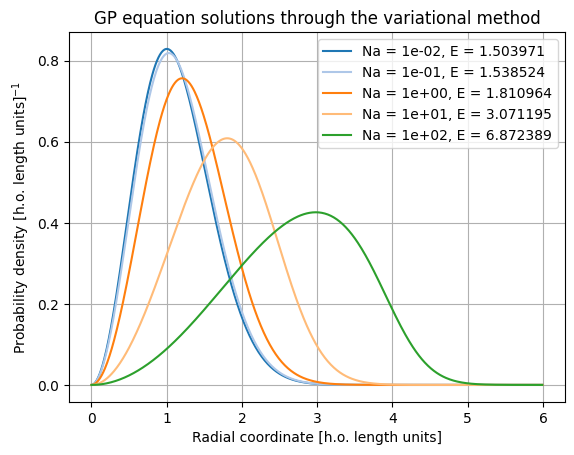

In [29]:
def iterative_GP_coeff_mixing(first_guess, alpha, nu, N, a, N_iterations, delta_E_stop,j):
    old_coord = first_guess.copy()
    old_coord /= np.linalg.norm(old_coord)
    Delta_E=[]
    for i in range(N_iterations):
        new_mu, new_coord = ground_state(old_coord, old_coord, 1.0, nu, N, a)
        mixed_coord = alpha * new_coord + (1 - alpha) * old_coord
        mixed_coord /= np.linalg.norm(mixed_coord)
        E, E_difference = true_energy(mixed_coord, N, a, new_mu)
        Delta_E.append(E_difference)
        print(f"E at {i} iteration= {E}")
        print(f"Delta_E at {i} iteration= {E_difference}")
        #if i % 10 == 0:
            #plot_state(mixed_coord, E)
        if abs(E_difference) < delta_E_stop and i > 1:
            print("Convergence reached with delta_E criterion!")
            plot_state(mixed_coord, E, a,j)
            break
        old_coord = mixed_coord
    return new_mu, E, mixed_coord, Delta_E

first_guess=np.zeros(40)
first_guess[0]=1
mixing=0.9
j=0
Delta_E=[]
for a in [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]:
    if a>1e-3:
        mixing=0.01
    _,_,_,E_difference=iterative_GP_coeff_mixing(first_guess,mixing,0.5,1e3,a,301,1e-6,j)
    Delta_E.append(E_difference)
    j+=1


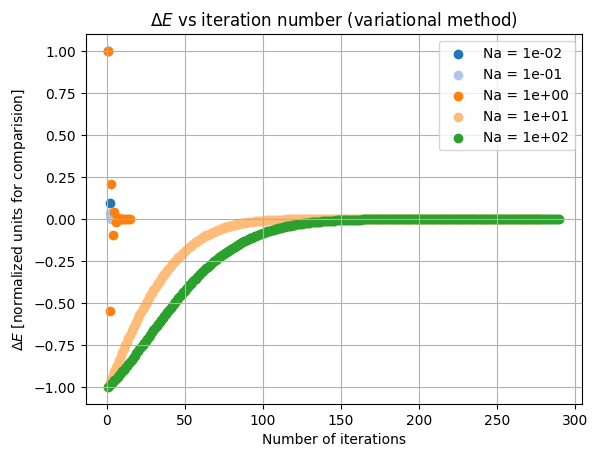

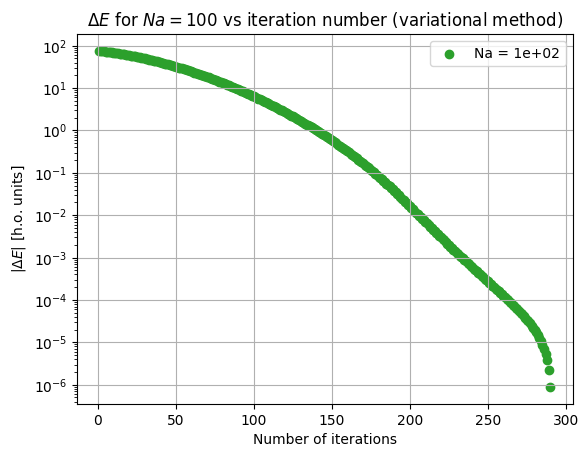

In [42]:

plt.figure()
cmap = plt.get_cmap('tab20')
for i in range(j):
    plt.scatter(np.arange(len(Delta_E[i]))+1,Delta_E[i]/np.max(np.abs(Delta_E[i])),color = cmap(i), label = f'Na = {1e-5*10**(i)*1000:.0e}')
    plt.xlabel("Number of iterations")
    plt.ylabel("$\Delta E$ [normalized units for comparision]")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.title("$\Delta E$ vs iteration number (variational method)")
plt.figure()
plt.scatter(np.arange(len(Delta_E[4]))+1,np.abs(Delta_E[4]),color = cmap(i), label = f'Na = {1e-5*10**(i)*1000:.0e}')
plt.xlabel("Number of iterations")
plt.ylabel("$|\Delta E|$ [h.o. units]")
plt.legend(loc='upper right')
plt.grid(True)
plt.title("$\Delta E$ for $Na=100$ vs iteration number (variational method)")
plt.yscale("log")

E at 0 iteration= 1.4960118612940843
Delta_E at 0 iteration= -8.680290673371283e-06
E at 1 iteration= 1.4960096664790987
Delta_E at 1 iteration= -6.785859367249708e-06
E at 2 iteration= 1.496007885843012
Delta_E at 2 iteration= -5.274380512178614e-06
E at 3 iteration= 1.4960064412266554
Delta_E at 3 iteration= -4.071059538122285e-06
E at 4 iteration= 1.496005269220234
Delta_E at 4 iteration= -3.11546745192931e-06
E at 5 iteration= 1.4960043183799687
Delta_E at 5 iteration= -2.358804937502984e-06
E at 6 iteration= 1.4960035469699973
Delta_E at 6 iteration= -1.761685246690417e-06
E at 7 iteration= 1.4960029211303922
Delta_E at 7 iteration= -1.2923377082224574e-06
E at 8 iteration= 1.4960024133908951
Delta_E at 8 iteration= -9.251522760430481e-07
Convergence reached with delta_E criterion!
E at 0 iteration= 1.4598745063120913
Delta_E at 0 iteration= -0.0008655798198981129
E at 1 iteration= 1.4596512820799386
Delta_E at 1 iteration= -0.000686719724639559
E at 2 iteration= 1.459467514281154

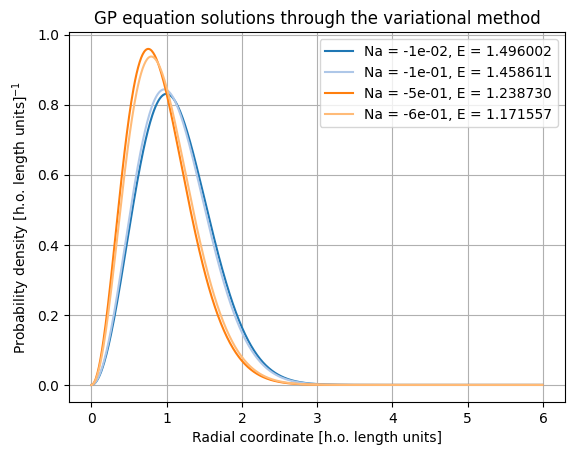

In [10]:
first_guess=np.zeros(40)
first_guess[0]=1
mixing=0.1
j=0
for a in [-1e-5, -1e-4, -0.5e-3, -0.6e-3]:
    #if abs(a)>0.5e-3:
    #    mixing=0.01
    iterative_GP_coeff_mixing(first_guess,mixing,0.5,1e3,a,1001,1e-6,j)
    j=j+1


In [ ]:
def imaginary_time_GP(first_guess, nu, N, a, N_iterations, delta_E_stop, dt=1e-2):
    psi = first_guess.copy().astype(float)
    psi /= np.linalg.norm(psi)
    E_old = np.inf
    for i in range(N_iterations):
        H = hamiltonian(psi, psi, 1.0, nu, N, a)
        psi_new = psi - dt * (H @ psi)
        psi_new /= np.linalg.norm(psi_new)
        E, E_difference = true_energy(psi_new, N, a, np.dot(psi_new, H @ psi_new))
        print(f"Iter {i:3d} | E={E:.8f} | Delta_E={E_difference:.2e} | dt={dt:.2e}")
        if E > E_old + 1e-10:
            dt *= 0.5
            print(f"E increased, dt reduced to {dt:.2e}")
            psi_new = psi  
        else:
            dt *= 1.05  
            dt = min(dt, 1e-1)
        if abs(E_difference) < delta_E_stop and i>1:
            print("Convergence!")
            plot_state(psi_new, E)
            break
        psi = psi_new
        E_old = E
    else:
        print("Convergence failed")
    return E, psi

first_guess = np.zeros(30)
first_guess[0]=1

for a in [1e-5,1e-4,1e-3,1e-2,1e-1]:
    imaginary_time_GP(first_guess,0.5,1e3,a,301,1e-6)

Iter   0 | E=1.50398475 | Delta_E=6.96e-07 | dt=1.00e-02
Iter   1 | E=1.50398407 | Delta_E=7.10e-07 | dt=1.05e-02
Iter   2 | E=1.50398340 | Delta_E=7.23e-07 | dt=1.10e-02
Convergence!


TypeError: plot_state() missing 2 required positional arguments: 'a' and 'i'